# Personal notebook — Aleksi — kNN experiments

**Purpose**: my personal working notebook for tuning k-Nearest-Neighbors on the CICIDS2017 dataset.
The final best result will be copied back to the group's `assignment1_template.ipynb`.

**Workflow reminders**
- Shared decisions (must match the group notebook): `random_state=42`, `f1_macro` scoring, the 10 `FEATURES` below, pipeline order Scaler → PCA → SMOTE → Classifier.
- Before committing to GitHub: Kernel → Restart & Run All**.

**Why kNN benefits from this pipeline**
- kNN measures distances between points, so scaling is mandatory, without it, features with large numeric ranges (like Flow Duration in microseconds) would dominate every distance.
- kNN is also very sensitive to class imbalance: a minority-class point gets outvoted by nearby majority-class neighbors. SMOTE should help a lot here — much more than it helps tree-based models.
- kNN scales poorly with the number of features ("curse of dimensionality"). PCA may help by projecting to fewer dimensions.

---
## 1. Imports and data

In [3]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Pipeline + preprocessing + evaluation
from imblearn.pipeline import Pipeline          # NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                             ConfusionMatrixDisplay,
                             accuracy_score, f1_score)

# The algorithm itself
from sklearn.neighbors import KNeighborsClassifier

## 2. Load the shared 100k sample and split 60/20/20

Uses the exact same code as the group notebook, so the splits are identical to every teammate's.

In [4]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


## 3. Shared skeleton (identical to the group notebook)

In [5]:
# ---- Agreed 10-feature list ------------------------------------------
FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 5
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True):
    """Fit Pipeline+GridSearchCV and return a results dict."""
    steps = [("scaler", StandardScaler())]
    steps.append(("pca",   PCA() if use_pca else "passthrough"))
    steps.append(("smote", SMOTE(random_state=42) if use_smote else "passthrough"))
    steps.append(("clf",   clf))
    pipe = Pipeline(steps)

    grid = GridSearchCV(pipe, param_grid=param_grid,
                        cv=CV_FOLDS, scoring=SCORING,
                        n_jobs=N_JOBS, verbose=1)
    grid.fit(X_train_sel, y_train)

    y_val_pred  = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc  = accuracy_score(y_val,  y_val_pred)
    val_f1   = f1_score(y_val, y_val_pred, average="macro")
    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1  = f1_score(y_test, y_test_pred, average="macro")

    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"{label} — test confusion matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params :", grid.best_params_)
    print(f"Val  acc={val_acc:.4f}  f1_macro={val_f1:.4f}")
    print(f"Test acc={test_acc:.4f}  f1_macro={test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label":         label,
        "best_params":   grid.best_params_,
        "val_acc":       val_acc,
        "val_f1_macro":  val_f1,
        "test_acc":      test_acc,
        "test_f1_macro": test_f1,
        "smote":         use_smote,
        "pca":           use_pca,
    }

all_results = []

## 4. Smoke test — one config, fast run

Prove the pipeline works end-to-end before committing to a long grid search.

Fitting 5 folds for each of 1 candidates, totalling 5 fits


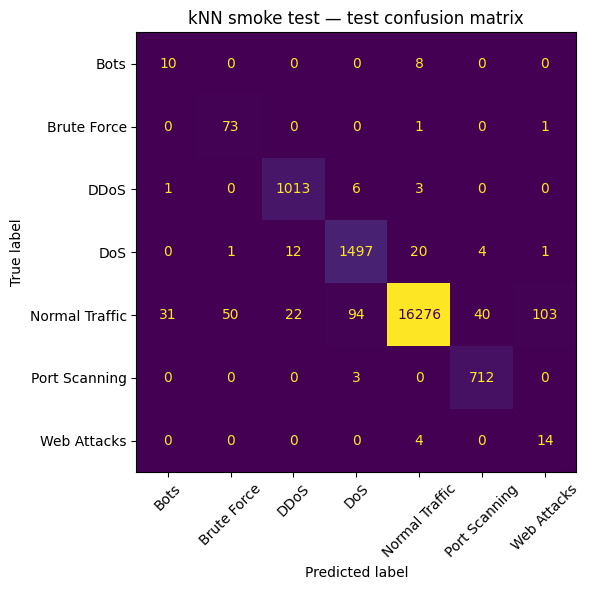


=== kNN smoke test ===
Best params : {'clf__n_neighbors': 5, 'clf__weights': 'distance', 'pca__n_components': 8}
Val  acc=0.9798  f1_macro=0.7531
Test acc=0.9798  f1_macro=0.7374
                precision    recall  f1-score   support

          Bots      0.238     0.556     0.333        18
   Brute Force      0.589     0.973     0.734        75
          DDoS      0.968     0.990     0.979      1023
           DoS      0.936     0.975     0.955      1535
Normal Traffic      0.998     0.980     0.989     16616
 Port Scanning      0.942     0.996     0.968       715
   Web Attacks      0.118     0.778     0.204        18

      accuracy                          0.980     20000
     macro avg      0.684     0.892     0.737     20000
  weighted avg      0.986     0.980     0.983     20000



In [6]:
knn_smoke_grid = {
    "pca__n_components": [8],
    "clf__n_neighbors":  [5],
    "clf__weights":      ["distance"],
}

smoke_result = run_experiment(
    KNeighborsClassifier(), knn_smoke_grid,
    label="kNN smoke test",
)
all_results.append(smoke_result)

## 5. Full grid — kNN + SMOTE + PCA

The main experiment. 3 × 4 × 2 = 24 combinations × 5 folds = 120 model fits.
kNN trains fast but predicts slowly (distance to every training point), and SMOTE inflates training size.

**Hyperparameter cheat-sheet for kNN:**
- `n_neighbors` (k): how many nearest neighbors vote on the class. Small k = flexible, noisy. Large k = smoother, may miss minority classes.
- `weights`: `"uniform"` = every neighbor votes equally. `"distance"` = closer neighbors get more weight. `"distance"` usually wins under imbalance.
- `pca__n_components`: how many principal components to keep. Fewer = less noise, faster kNN. Too few = information loss.

Fitting 5 folds for each of 24 candidates, totalling 120 fits


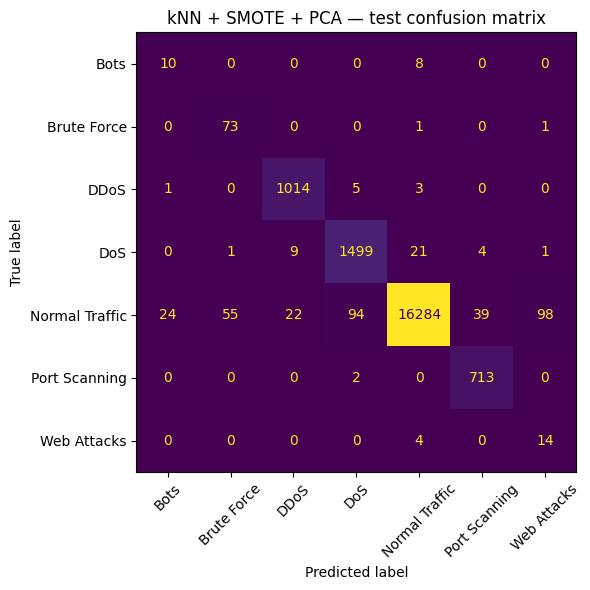


=== kNN + SMOTE + PCA ===
Best params : {'clf__n_neighbors': 3, 'clf__weights': 'distance', 'pca__n_components': 8}
Val  acc=0.9801  f1_macro=0.7569
Test acc=0.9804  f1_macro=0.7429
                precision    recall  f1-score   support

          Bots      0.286     0.556     0.377        18
   Brute Force      0.566     0.973     0.716        75
          DDoS      0.970     0.991     0.981      1023
           DoS      0.937     0.977     0.956      1535
Normal Traffic      0.998     0.980     0.989     16616
 Port Scanning      0.943     0.997     0.969       715
   Web Attacks      0.123     0.778     0.212        18

      accuracy                          0.980     20000
     macro avg      0.689     0.893     0.743     20000
  weighted avg      0.987     0.980     0.983     20000



In [7]:
knn_grid = {
    "pca__n_components": [4, 6, 8],
    "clf__n_neighbors":  [3, 5, 7, 11],
    "clf__weights":      ["uniform", "distance"],
}

result_full = run_experiment(
    KNeighborsClassifier(), knn_grid,
    label="kNN + SMOTE + PCA",
)
all_results.append(result_full)

## 6. No-SMOTE baseline — is SMOTE actually helping?

The assignment brief asks us to report this. kNN is **very** sensitive to class imbalance, so SMOTE should have a big positive effect here — unlike tree-based models.

We reuse the winning hyperparameters from the full run so the comparison is fair.

Fitting 5 folds for each of 1 candidates, totalling 5 fits


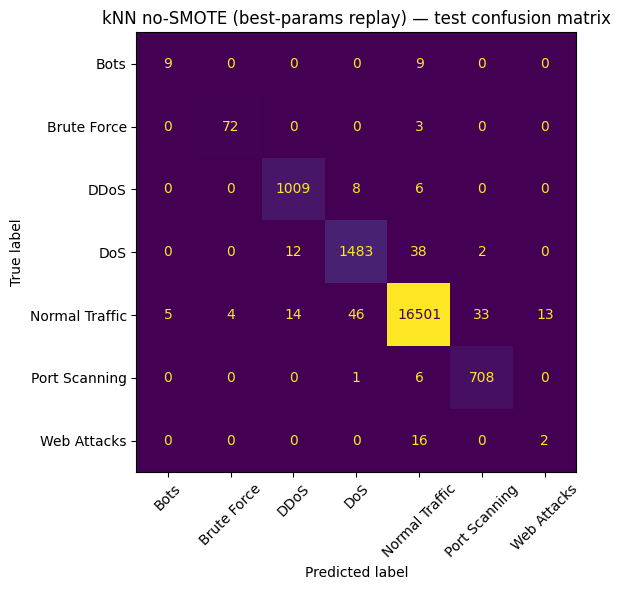


=== kNN no-SMOTE (best-params replay) ===
Best params : {'clf__n_neighbors': 3, 'clf__weights': 'distance', 'pca__n_components': 8}
Val  acc=0.9899  f1_macro=0.7933
Test acc=0.9892  f1_macro=0.7926
                precision    recall  f1-score   support

          Bots      0.643     0.500     0.562        18
   Brute Force      0.947     0.960     0.954        75
          DDoS      0.975     0.986     0.981      1023
           DoS      0.964     0.966     0.965      1535
Normal Traffic      0.995     0.993     0.994     16616
 Port Scanning      0.953     0.990     0.971       715
   Web Attacks      0.133     0.111     0.121        18

      accuracy                          0.989     20000
     macro avg      0.802     0.787     0.793     20000
  weighted avg      0.989     0.989     0.989     20000



In [8]:
best_k       = result_full["best_params"]["clf__n_neighbors"]
best_weights = result_full["best_params"]["clf__weights"]
best_pca     = result_full["best_params"]["pca__n_components"]

nosmote_grid = {
    "pca__n_components": [best_pca],
    "clf__n_neighbors":  [best_k],
    "clf__weights":      [best_weights],
}

result_no_smote = run_experiment(
    KNeighborsClassifier(), nosmote_grid,
    label="kNN no-SMOTE (best-params replay)",
    use_smote=False,
)
all_results.append(result_no_smote)

## 7. No-PCA baseline — is PCA actually helping?

Keep SMOTE on, drop PCA. kNN might actually benefit from PCA (curse of dimensionality), so this comparison is more interesting than it would be for trees.

Fitting 5 folds for each of 1 candidates, totalling 5 fits


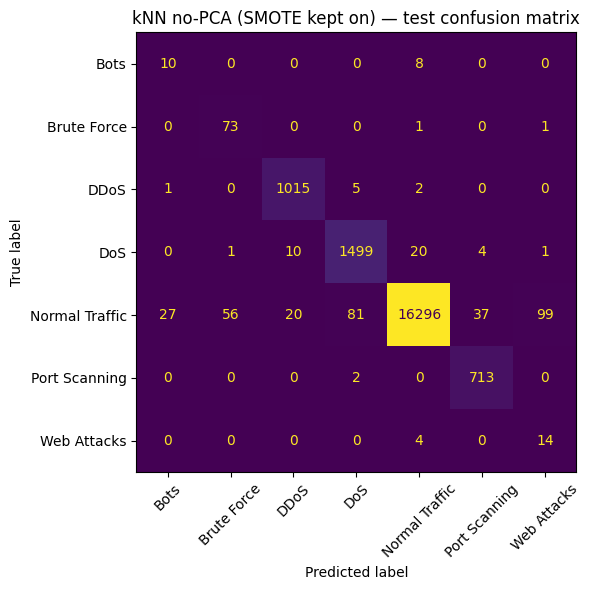


=== kNN no-PCA (SMOTE kept on) ===
Best params : {'clf__n_neighbors': 3, 'clf__weights': 'distance'}
Val  acc=0.9808  f1_macro=0.7582
Test acc=0.9810  f1_macro=0.7402
                precision    recall  f1-score   support

          Bots      0.263     0.556     0.357        18
   Brute Force      0.562     0.973     0.712        75
          DDoS      0.971     0.992     0.982      1023
           DoS      0.945     0.977     0.960      1535
Normal Traffic      0.998     0.981     0.989     16616
 Port Scanning      0.946     0.997     0.971       715
   Web Attacks      0.122     0.778     0.211        18

      accuracy                          0.981     20000
     macro avg      0.687     0.893     0.740     20000
  weighted avg      0.987     0.981     0.984     20000



In [9]:
nopca_grid = {
    "clf__n_neighbors": [best_k],
    "clf__weights":     [best_weights],
}

result_no_pca = run_experiment(
    KNeighborsClassifier(), nopca_grid,
    label="kNN no-PCA (SMOTE kept on)",
    use_pca=False,
)
all_results.append(result_no_pca)

## 8. Summary table for Section 10 handoff

Compare all runs side by side. Winner = highest `test_f1_macro`.

In [10]:
summary = pd.DataFrame(all_results)[
    ["label", "smote", "pca", "val_acc", "val_f1_macro",
     "test_acc", "test_f1_macro", "best_params"]
]
summary

,label,smote,pca,val_acc,val_f1_macro,test_acc,test_f1_macro,best_params
0,kNN smoke test,True,True,0.97980,0.753097,0.97975,0.737397,"{'clf__n_neighbors': 5, 'clf__weights': 'dista..."
1,kNN + SMOTE + PCA,True,True,0.98015,0.756895,0.98035,0.742904,"{'clf__n_neighbors': 3, 'clf__weights': 'dista..."
2,kNN no-SMOTE (best-params replay),False,True,0.98985,0.793316,0.98920,0.792640,"{'clf__n_neighbors': 3, 'clf__weights': 'dista..."
3,kNN no-PCA (SMOTE kept on),True,False,0.98075,0.758162,0.98100,0.740246,"{'clf__n_neighbors': 3, 'clf__weights': 'dista..."
